In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as feature

In [2]:
datadir = '/Users/CDKoven/datasets/flat10MIP_analysis/flat10/'

model_list = ['CESM2']

exp_list = ['flat10','flat10-zec','flat10-cdr']
exp_list_underscore = ['flat10','flat10_zec','flat10_cdr']
exp_list_giss = ['Flat10','Flat10zec','Flat10cdr']

year_ave_start = [90,90,90]

<xarray.DataArray 'tas' (lat: 192, lon: 288)>
dask.array<mean_agg-aggregate, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
<xarray.DataArray 'tas' (lat: 192, lon: 288)>
dask.array<mean_agg-aggregate, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
<xarray.DataArray 'tas' (lat: 192, lon: 288)>
dask.array<mean_agg-aggregate, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8


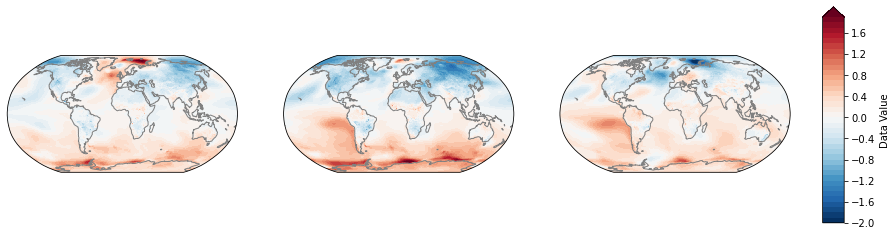

In [3]:
filenames = ['b.e21.B1850.f09_g17.FLAT10-esm.001.cam.h0.ts.allyears.tas.nc',
             'b.e21.B1850.f09_g17.FLAT10-zec.001.cam.h0.ts.allyears.tas.nc',
             'b.e21.B1850.f09_g17.FLAT10-cdr.001.cam.h0.ts.allyears.tas.nc']

data_in_cesm = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'CESM2' + '/' + exp_list[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(time=slice(90*12, 110*12)).mean(dim='time')
    print(tas_mean)
    data_in_cesm.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_cesm[1]-data_in_cesm[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_cesm[2]-data_in_cesm[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_cesm[2]-data_in_cesm[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


<xarray.DataArray 'tas' (lat: 180, lon: 288)>
dask.array<mean_agg-aggregate, shape=(180, 288), dtype=float32, chunksize=(180, 288), chunktype=numpy.ndarray>
Coordinates:
    height   float64 2.0
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.625 1.875 3.125 4.375 ... 355.6 356.9 358.1 359.4


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


<xarray.DataArray 'tas' (lat: 180, lon: 288)>
dask.array<mean_agg-aggregate, shape=(180, 288), dtype=float32, chunksize=(180, 288), chunktype=numpy.ndarray>
Coordinates:
    height   float64 2.0
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.625 1.875 3.125 4.375 ... 355.6 356.9 358.1 359.4


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


<xarray.DataArray 'tas' (lat: 180, lon: 288)>
dask.array<mean_agg-aggregate, shape=(180, 288), dtype=float32, chunksize=(180, 288), chunktype=numpy.ndarray>
Coordinates:
    height   float64 2.0
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.625 1.875 3.125 4.375 ... 355.6 356.9 358.1 359.4


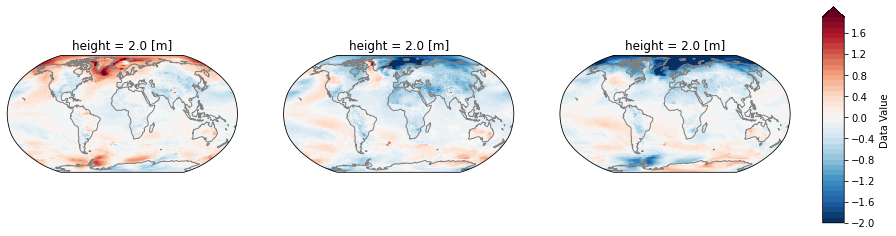

In [4]:
filenames = ['tas_Amon_GFDL-ESM4_flat10_r1i1p1f1_gr_*.nc',
             'tas_Amon_GFDL-ESM4_flat10-zec_r1i1p1f1_gr_*.nc',
             'tas_Amon_GFDL-ESM4_flat10-cdr_r1i1p1f1_gr_*.nc']

data_in_gfdl = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'GFDL-ESM4' + '/' + exp_list[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(time=slice(90*12, 110*12)).mean(dim='time')
    print(tas_mean)
    data_in_gfdl.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_gfdl[1]-data_in_gfdl[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_gfdl[2]-data_in_gfdl[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_gfdl[2]-data_in_gfdl[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

<xarray.DataArray 'air_temperature' (latitude: 144, longitude: 192)>
dask.array<mean_agg-aggregate, shape=(144, 192), dtype=float32, chunksize=(144, 192), chunktype=numpy.ndarray>
Coordinates:
  * latitude                 (latitude) float32 -89.38 -88.12 ... 88.12 89.38
  * longitude                (longitude) float32 0.9375 2.812 ... 357.2 359.1
    forecast_reference_time  object ...
    height                   float64 ...
<xarray.DataArray 'air_temperature' (latitude: 144, longitude: 192)>
dask.array<mean_agg-aggregate, shape=(144, 192), dtype=float32, chunksize=(144, 192), chunktype=numpy.ndarray>
Coordinates:
  * latitude                 (latitude) float32 -89.38 -88.12 ... 88.12 89.38
  * longitude                (longitude) float32 0.9375 2.812 ... 357.2 359.1
    forecast_reference_time  object ...
    height                   float64 ...
<xarray.DataArray 'air_temperature' (latitude: 144, longitude: 192)>
dask.array<mean_agg-aggregate, shape=(144, 192), dtype=float32, chunksi

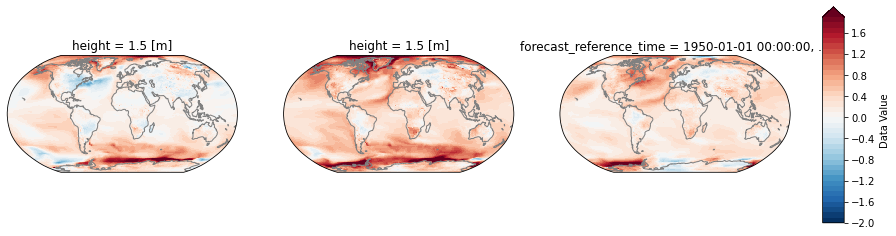

In [5]:
filenames = ['dg403_flat10_tas.nc',
             'dg492_flat10-zec_tas.nc',
             'dg493_flat10-cdr_tas.nc']

data_in_ukesm = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'UKESM1.2' + '/' + exp_list[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['air_temperature'].isel(time=slice(90, 110)).mean(dim='time')
    print(tas_mean)
    data_in_ukesm.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_ukesm[1]-data_in_ukesm[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_ukesm[2]-data_in_ukesm[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_ukesm[2]-data_in_ukesm[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

<xarray.DataArray 'tas' (lat: 64, lon: 128)>
dask.array<mean_agg-aggregate, shape=(64, 128), dtype=float32, chunksize=(64, 128), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * lat      (lat) float64 87.86 85.1 82.31 79.53 ... -79.53 -82.31 -85.1 -87.86
<xarray.DataArray 'tas' (lat: 64, lon: 128)>
dask.array<mean_agg-aggregate, shape=(64, 128), dtype=float32, chunksize=(64, 128), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * lat      (lat) float64 87.86 85.1 82.31 79.53 ... -79.53 -82.31 -85.1 -87.86
<xarray.DataArray 'tas' (lat: 64, lon: 128)>
dask.array<mean_agg-aggregate, shape=(64, 128), dtype=float32, chunksize=(64, 128), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * lat      (lat) float64 87.86 85.1 82.31 79.53 ... -79.53 -82.31 -85.1 -87.86


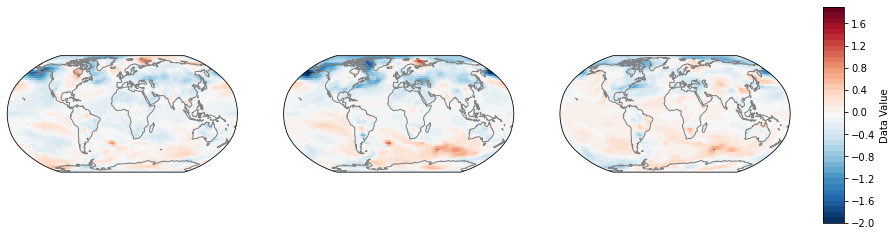

In [6]:
filenames = ['tas_flat10_miroc-es2l.nc',
             'tas_flat10zec_miroc-es2l.nc',
             'tas_flat10cdr_miroc-es2l.nc']

data_in_miroc = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'miroc-es2l' + '/' + exp_list_underscore[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(time=slice(90*12, 110*12)).mean(dim='time')
    print(tas_mean)
    data_in_miroc.append(tas_mean)
    ds.close()

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_miroc[1]-data_in_miroc[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_miroc[2]-data_in_miroc[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_miroc[2]-data_in_miroc[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: 

<xarray.DataArray 'tas' (lat: 96, lon: 192)>
dask.array<mean_agg-aggregate, shape=(96, 192), dtype=float32, chunksize=(96, 192), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 -88.57 -86.72 -84.86 -83.0 ... 83.0 84.86 86.72 88.57
    height   float64 ...


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


<xarray.DataArray 'tas' (lat: 96, lon: 192)>
dask.array<mean_agg-aggregate, shape=(96, 192), dtype=float32, chunksize=(96, 192), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 -88.57 -86.72 -84.86 -83.0 ... 83.0 84.86 86.72 88.57
    height   float64 ...


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


<xarray.DataArray 'tas' (lat: 96, lon: 192)>
dask.array<mean_agg-aggregate, shape=(96, 192), dtype=float32, chunksize=(96, 192), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 -88.57 -86.72 -84.86 -83.0 ... 83.0 84.86 86.72 88.57
    height   float64 ...


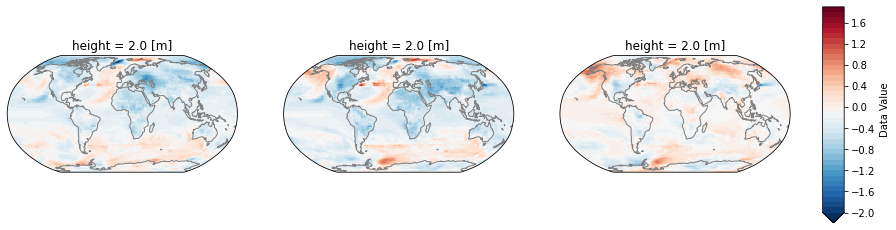

In [7]:
filenames = ['flat10_tas_MPI-ESM1-2-LR.nc',
             'flat10_zec_tas_MPI-ESM1-2-LR.nc',
             'flat10_cdr_tas_MPI-ESM1-2-LR.nc']

data_in_mpi = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'MPI-ESM1-2-LR' + '/' + exp_list_underscore[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(time=slice(90*12, 110*12)).mean(dim='time')
    print(tas_mean)
    data_in_mpi.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_mpi[1]-data_in_mpi[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_mpi[2]-data_in_mpi[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_mpi[2]-data_in_mpi[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

<xarray.DataArray 'temp_mm_1_5m' (latitude: 73, longitude: 96)>
dask.array<mean_agg-aggregate, shape=(73, 96), dtype=float32, chunksize=(73, 96), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * longitude  (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
    ht         float32 ...
<xarray.DataArray 'temp_mm_1_5m' (latitude: 73, longitude: 96)>
dask.array<mean_agg-aggregate, shape=(73, 96), dtype=float32, chunksize=(73, 96), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * longitude  (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
    ht         float32 ...
<xarray.DataArray 'temp_mm_1_5m' (latitude: 73, longitude: 96)>
dask.array<mean_agg-aggregate, shape=(73, 96), dtype=float32, chunksize=(73, 96), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * longitude 

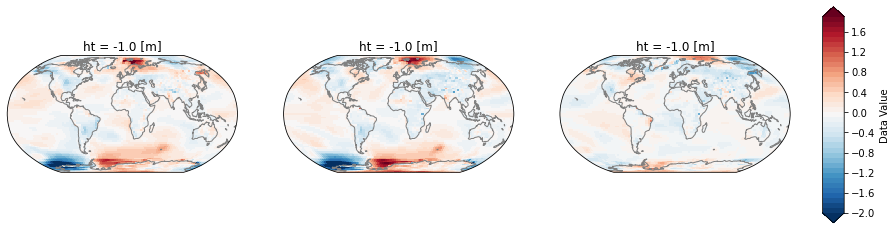

In [8]:
filenames = ['flat10_tas_annual_full2D_HadCM3LC-Bris.nc',
             'flat10-zec_tas_annual_full2D_HadCM3LC-Bris.nc',
             'flat10-cdr_tas_annual_full2D_HadCM3LC-Bris.nc']

data_in_hadcm3lc3 = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'HadCM3LC-Bris' + '/' + exp_list[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['temp_mm_1_5m'].isel(time=slice(90, 110)).mean(dim='time')
    print(tas_mean)
    data_in_hadcm3lc3.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_hadcm3lc3[1]-data_in_hadcm3lc3[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_hadcm3lc3[2]-data_in_hadcm3lc3[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_hadcm3lc3[2]-data_in_hadcm3lc3[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

<xarray.DataArray 'tas' (lat: 96, lon: 144)>
dask.array<mean_agg-aggregate, shape=(96, 144), dtype=float32, chunksize=(96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 2.0
<xarray.DataArray 'tas' (lat: 96, lon: 144)>
dask.array<mean_agg-aggregate, shape=(96, 144), dtype=float32, chunksize=(96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 2.0
<xarray.DataArray 'tas' (lat: 96, lon: 144)>
dask.array<mean_agg-aggregate, shape=(96, 144), dtype=float32, chunksize=(96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 35

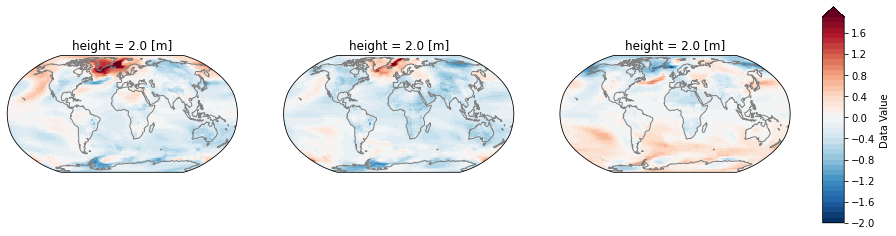

In [9]:
filenames = ['tas_Amon_NorESM2-LM_flat10_r1i1p1f1_gn_*.nc',
             'tas_Amon_NorESM2-LM_flat10_zec_r1i1p1f1_gn_*.nc',
             'tas_Amon_NorESM2-LM_flat10_cdr_r1i1p1f1_gn_*.nc']

data_in_noresm = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'NorESM2-LM' + '/' + exp_list_underscore[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(time=slice(90*12, 110*12)).mean(dim='time')
    print(tas_mean)
    data_in_noresm.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_noresm[1]-data_in_noresm[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_noresm[2]-data_in_noresm[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_noresm[2]-data_in_noresm[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

<xarray.DataArray 'tas' (lat: 90, lon: 144)>
dask.array<mean_agg-aggregate, shape=(90, 144), dtype=float32, chunksize=(90, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 -178.8 -176.2 -173.8 -171.2 ... 173.8 176.2 178.8
  * lat      (lat) float32 -90.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 90.0
<xarray.DataArray 'tas' (lat: 90, lon: 144)>
dask.array<mean_agg-aggregate, shape=(90, 144), dtype=float32, chunksize=(90, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 -178.8 -176.2 -173.8 -171.2 ... 173.8 176.2 178.8
  * lat      (lat) float32 -90.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 90.0
<xarray.DataArray 'tas' (lat: 90, lon: 144)>
dask.array<mean_agg-aggregate, shape=(90, 144), dtype=float32, chunksize=(90, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 -178.8 -176.2 -173.8 -171.2 ... 173.8 176.2 178.8
  * lat      (lat) float32 -90.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 90.0


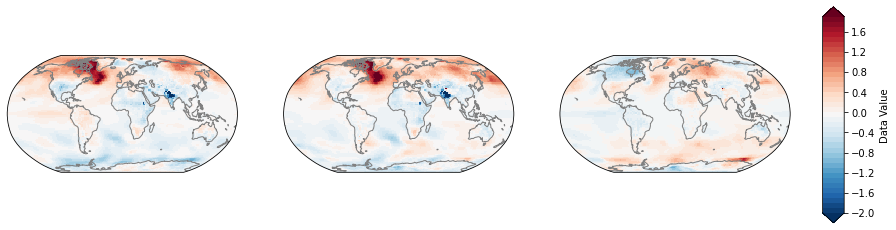

In [10]:
filenames = ['tas_Ayr_GISSE21obio12_flat10_1850_2050.nc',
             'tas_Ayr_GISSE21obio12_flat10zec_1950_2200.nc',
             'tas_Ayr_GISSE21obio12_flat10cdr_1950_2200.nc']

data_in_giss = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'GISS_E2.1' + '/' + exp_list_giss[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(year=slice(90, 110)).mean(dim='year')
    print(tas_mean)
    data_in_giss.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_giss[1]-data_in_giss[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_giss[2]-data_in_giss[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_giss[2]-data_in_giss[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

<xarray.DataArray 'tas' (lat: 128, lon: 256)>
dask.array<mean_agg-aggregate, shape=(128, 256), dtype=float32, chunksize=(128, 256), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 1.406 2.812 4.219 ... 354.4 355.8 357.2 358.6
  * lat      (lat) float64 -88.93 -87.54 -86.14 -84.74 ... 86.14 87.54 88.93
    height   float64 ...
<xarray.DataArray 'tas' (lat: 128, lon: 256)>
dask.array<mean_agg-aggregate, shape=(128, 256), dtype=float32, chunksize=(128, 256), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -88.93 -87.54 -86.14 -84.74 ... 86.14 87.54 88.93
  * lon      (lon) float64 0.0 1.406 2.812 4.219 ... 354.4 355.8 357.2 358.6
    height   float64 ...
<xarray.DataArray 'tas' (lat: 128, lon: 256)>
dask.array<mean_agg-aggregate, shape=(128, 256), dtype=float32, chunksize=(128, 256), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -88.93 -87.54 -86.14 -84.74 ... 86.14 87.54 88.93
  * lon      (lon) float64 0.0 1.406 2.812 4.219 ... 35

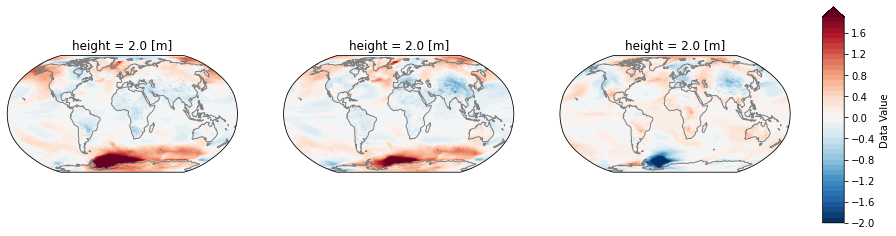

In [11]:
filenames = ['flat10_tas_Amon_CNRM-ESM2-1.nc',
             'flat10-zec_tas_Amon_CNRM-ESM2-1.nc',
             'flat10-cdr_tas_Amon_CNRM-ESM2-1.nc']

data_in_cnrm = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'CNRM-ESM2-1' + '/' + exp_list[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(time=slice(90*12, 110*12)).mean(dim='time')
    print(tas_mean)
    data_in_cnrm.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_cnrm[1]-data_in_cnrm[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_cnrm[2]-data_in_cnrm[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_cnrm[2]-data_in_cnrm[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557:

<xarray.DataArray 'tas' (lat: 145, lon: 192)>
dask.array<mean_agg-aggregate, shape=(145, 192), dtype=float32, chunksize=(145, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.75 -87.5 -86.25 ... 86.25 87.5 88.75 90.0
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
    height   float64 2.0
<xarray.DataArray 'tas' (lat: 145, lon: 192)>
dask.array<mean_agg-aggregate, shape=(145, 192), dtype=float32, chunksize=(145, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.75 -87.5 -86.25 ... 86.25 87.5 88.75 90.0
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
    height   float64 2.0
<xarray.DataArray 'tas' (lat: 145, lon: 192)>
dask.array<mean_agg-aggregate, shape=(145, 192), dtype=float32, chunksize=(145, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.75 -87.5 -86.25 ... 86.25 87.5 88.75 90.0
  * lon      (lon) float64 0.0 1.875 3.75 5

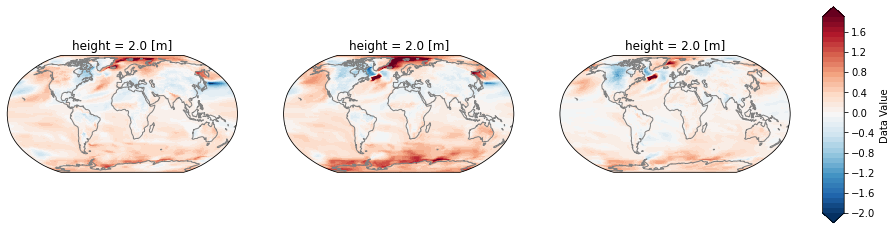

In [12]:
filenames = ['tas_Amon_ACCESS-ESM1-5_flat10_r1i1p1f2_gn_*.nc',
             'tas_Amon_ACCESS-ESM1-5_flat10_zec_r1i1p1f2_gn_*.nc',
             'tas_Amon_ACCESS-ESM1-5_flat10_cdr_r1i1p1f3_gn_*.nc']

data_in_access = []
for exp_i in range(len(exp_list)):
    fname = datadir + 'ACCESS-ESM1-5' + '/' + exp_list_underscore[exp_i] + '/' + filenames[exp_i]
    ds = xr.open_mfdataset(fname)
    tas_mean = ds['tas'].isel(time=slice(90*12, 110*12)).mean(dim='time')
    print(tas_mean)
    data_in_access.append(tas_mean)

fig, axs = plt.subplots(1, 3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

p = (data_in_access[1]-data_in_access[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_access[2]-data_in_access[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

(data_in_access[2]-data_in_access[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
fig.colorbar(p, cbar_ax, label='Data Value')
    
plt.show()

    

In [13]:
models_list = ['ACCESS-ESM1-5',
'CESM2',
'CNRM-ESM2-1',
'GFDL-ESM4',
'GISS_E2.1',
'HadCM3LC-Bris',
'MPI-ESM1-2-LR',
'NorESM2-LM',
'UKESM1.2',
'MIROC-ES2L']

nmodels = len(models_list)

data_dict = {'ACCESS-ESM1-5':data_in_access,
'CESM2':data_in_cesm,
'CNRM-ESM2-1':data_in_cnrm,
'GFDL-ESM4':data_in_gfdl,
'GISS_E2.1':data_in_giss,
'HadCM3LC-Bris':data_in_hadcm3lc3,
'MPI-ESM1-2-LR':data_in_mpi,
'NorESM2-LM':data_in_noresm,
'UKESM1.2':data_in_ukesm,
'MIROC-ES2L':data_in_miroc}

/var/folders/6g/x_x6jm6s1jq6fz2gmv70hhdh0000gp/T/ipykernel_81219/2904775956.py:30: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


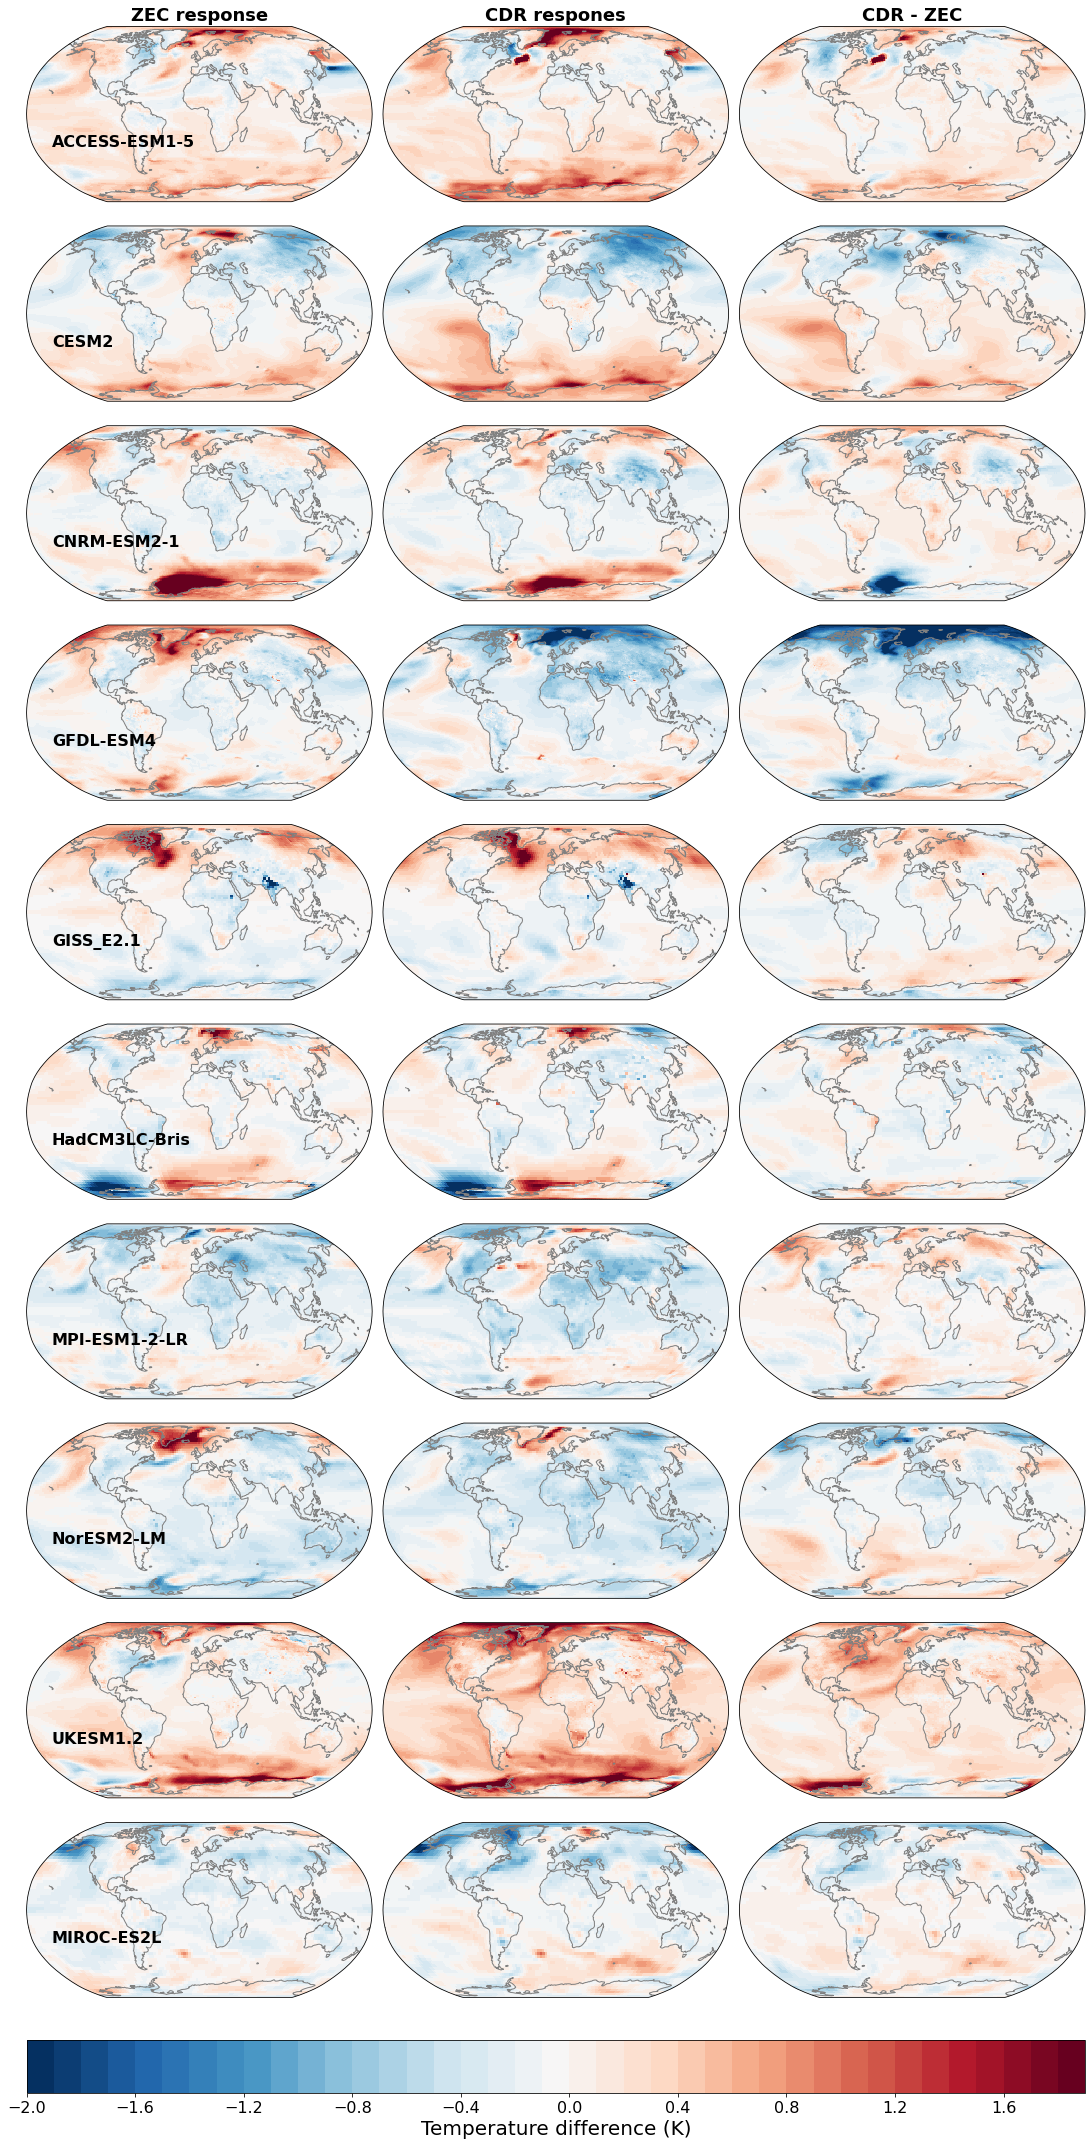

In [14]:
fig, axs = plt.subplots(nmodels, 3, figsize=(15, 30),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)
p
for model_i, model in enumerate(models_list):
    data = data_dict[model]
    p = (data[1]-data[0]).plot(ax=axs[model_i,0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
    axs[model_i,0].add_feature(feature.COASTLINE, edgecolor='grey')

    (data[2]-data[0]).plot(ax=axs[model_i,1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
    axs[model_i,1].add_feature(feature.COASTLINE, edgecolor='grey')

    (data[2]-data[1]).plot(ax=axs[model_i,2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
    axs[model_i,2].add_feature(feature.COASTLINE, edgecolor='grey')

# 3. Label the columns (set titles for the top row)
column_labels = ['ZEC response', 'CDR respones', 'CDR - ZEC']
for ax, col in zip(axs[0, :], column_labels):
    ax.set_title(col, size=18, fontweight='bold')

for i in range(2,nmodels):
    for ax, col in zip(axs[i, :], column_labels):
        ax.set_title('')

# 4. Label the rows (set y-labels for the first column)
row_labels = models_list
for ax, row in zip(axs[:, 0], row_labels):
    ax.text(200., -30., row, transform=ccrs.Geodetic(), size=16, fontweight='bold')
    
plt.tight_layout()

cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.04, pad=0.02, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label('Temperature difference (K)', fontsize=20) # Large font for the label


plt.show()
